In [ ]:
# Tissue Spatial Geometrics Lab | David Nguyen, PhD

# This script was written to take in the fft out from the LCPC scripts. The input data should be formatted like in the image.
# This script uses median standardization to standardize the data before doing PCA, because the results from the LCPC scripts
#   inherently has outliers (example: the value of the first bin is usually much larger than other bins).

# Outputs from this script:
# 1. A csv file containig the scores for each of the first 3 principal components. This output file has the "_1st3PCvalues.csv" as a suffix
#      added to the name of the input file. 
# 2. A csv file containing the loading values resulting from the PCA. The output file has "_loading_plot_data.csv" as a suffix
#      added to the name of the input file. 
# 3. It prints a 3D dotplot of the first 3 PCs, shown as a graph in this notebook.
# 4. It prints a Scree plot of the PCs, shown as a graph in this notebook.
# 5. It prints biplot of the first two PCs, shown as a graph in this notebook.

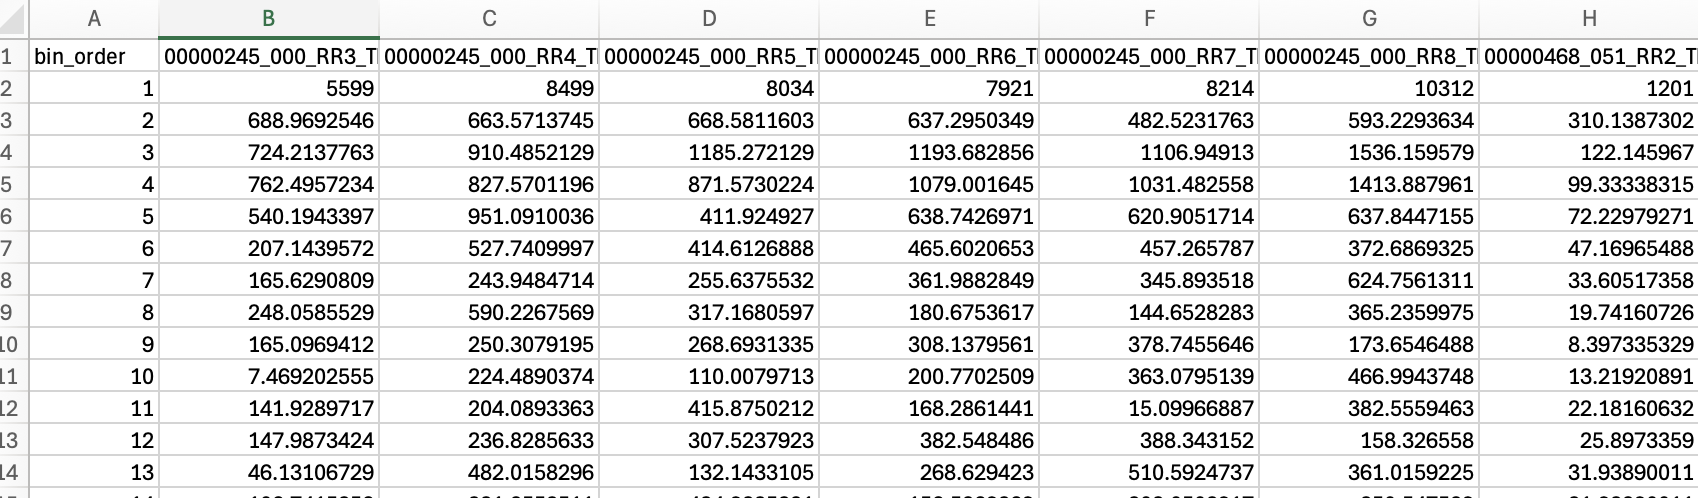

In [1]:
# Load dependencies

import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import RobustScaler

In [5]:
# Set the working directory
os.chdir('/Users/davidnguyen/Downloads/Practice File/Example INPUT')

# Load the CSV file 
file_path = "LCPC Data for Practicing PCA.csv"  # Update with the actual file name
df = pd.read_csv(file_path)

# Fill empty cells with zeros
df = df.fillna(0)
df.head()

,bin_order,CN-1,CN-2,CN-3,CN-4,CN-5,CN-6,CN-7,CN-8,CN-9,...,AD-5,AD-6,AD-7,AD-8,AD-9,AD-10,AD-11,AD-12,AD-13,AD-14
0,1,640.000000,484.000000,988.000000,1335.000000,525.000000,1159.000000,516.000000,576.000000,1452.000000,...,616.000000,1430.000000,1788.000000,1254.000000,3698.000000,714.000000,2026.000000,6759.000000,752.000000,872.000000
1,2,133.539324,132.798425,132.730487,140.309455,102.322617,269.623701,140.220737,140.229022,117.390251,...,95.901469,158.682288,208.609984,186.116260,1259.671245,159.449312,552.123943,2203.238686,133.016216,192.602650
2,3,57.244711,78.610644,152.519879,217.465976,62.090984,167.203746,67.739466,85.858303,95.867273,...,99.809104,155.547183,234.753585,143.278330,548.554970,60.305205,295.439780,872.413179,68.565976,91.663789
3,4,57.921638,41.867728,96.526520,147.474820,47.678025,70.924810,48.000000,52.252971,126.571428,...,74.006558,105.429960,205.471610,105.819778,490.225581,42.415526,155.681847,1123.845674,55.614052,85.965221
4,5,39.549460,27.013270,84.787977,118.860711,38.303914,46.031595,41.651778,45.385147,127.019904,...,50.835310,125.939478,161.826819,105.649299,645.543581,49.308692,152.923233,1373.464604,51.901350,63.043930


In [3]:
# Extract base name without suffix for naming the output files of this script
base_name = os.path.splitext(os.path.basename(file_path))[0]
base_name

'LCPC Data for Practicing PCA'

In [4]:
# Transpose the dataframe so that samples are rows and features are columns
df_transposed = df.T
df_transposed.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
bin_order,1.0,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,...,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0
CN-1,640.0,133.539324,57.244711,57.921638,39.549460,32.649655,31.241687,20.054047,11.438541,8.612079,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-2,484.0,132.798425,78.610644,41.867728,27.013270,11.174667,8.467710,16.295111,24.046116,24.046116,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-3,988.0,132.730487,152.519879,96.526520,84.787977,52.876709,21.739397,22.115053,14.309081,5.499287,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-4,1335.0,140.309455,217.465976,147.474820,118.860711,96.249675,74.226373,51.301846,29.411614,34.469950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Set the first row as the column names
df_transposed.columns = df_transposed.iloc[0]    
df_transposed.head()

bin_order,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0
bin_order,1.0,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,...,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0
CN-1,640.0,133.539324,57.244711,57.921638,39.549460,32.649655,31.241687,20.054047,11.438541,8.612079,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-2,484.0,132.798425,78.610644,41.867728,27.013270,11.174667,8.467710,16.295111,24.046116,24.046116,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-3,988.0,132.730487,152.519879,96.526520,84.787977,52.876709,21.739397,22.115053,14.309081,5.499287,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-4,1335.0,140.309455,217.465976,147.474820,118.860711,96.249675,74.226373,51.301846,29.411614,34.469950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Drop the original first row 
df_transposed = df_transposed.iloc[1:]
df_transposed.head()

bin_order,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0
CN-1,640.0,133.539324,57.244711,57.921638,39.549460,32.649655,31.241687,20.054047,11.438541,8.612079,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-2,484.0,132.798425,78.610644,41.867728,27.013270,11.174667,8.467710,16.295111,24.046116,24.046116,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-3,988.0,132.730487,152.519879,96.526520,84.787977,52.876709,21.739397,22.115053,14.309081,5.499287,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-4,1335.0,140.309455,217.465976,147.474820,118.860711,96.249675,74.226373,51.301846,29.411614,34.469950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-5,525.0,102.322617,62.090984,47.678025,38.303914,33.001623,26.144040,17.170467,5.192777,5.192777,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Extract sample names (original column names from CSV). Make sure the first item is not bin_order
sample_names = df_transposed.index
sample_names[0:5]

Index(['CN-1', 'CN-2', 'CN-3', 'CN-4', 'CN-5'], dtype='object')

# MEDIAN Standardization for PCA

In [8]:
# Apply the method to numerical columns of the data frame
# get the names of ONLY the numerical columns in the df
numerical_cols = df_transposed.select_dtypes(include=['number']).columns
numerical_cols

Index([ 1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,  8.0,  9.0, 10.0, 11.0, 12.0,
       13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0,
       25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0,
       37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0],
      dtype='float64', name='bin_order')

In [9]:
#  Then apply the scaler to only the numerical columns of interest, while preserving the categorical columns
robust_scaler = RobustScaler()

df_transposed[numerical_cols] = robust_scaler.fit_transform(df_transposed[numerical_cols])
df_transposed.head()

bin_order,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0
CN-1,-0.317867,-0.299004,-0.405328,-0.348970,-0.250523,-0.240097,-0.036548,-0.112439,-0.191301,-0.405816,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-2,-0.533934,-0.311191,-0.168197,-0.634454,-0.415574,-0.538054,-0.368575,-0.173291,0.015144,-0.035988,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-3,0.164127,-0.312308,0.652087,0.337535,0.345088,0.040546,-0.175084,-0.079074,-0.144297,-0.480404,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-4,0.644737,-0.187651,1.372894,1.243542,0.793689,0.642329,0.590136,0.393417,0.103002,0.213787,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN-5,-0.477147,-0.812451,-0.351541,-0.531131,-0.266921,-0.235213,-0.110868,-0.159120,-0.293574,-0.487749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# PCA

In [10]:
# Perform PCA with 3 components
pca = PCA()
principal_components = pca.fit_transform(df_transposed)

# Use only the first 3 components for plotting and saving
pc_df = pd.DataFrame(principal_components[:, :3], columns=["PC1", "PC2", "PC3"])
pc_df.insert(0, "Sample_Name", sample_names)

pc_df.head()

# Save values of first 3 PCs as csv file
# Create new output filename
fileName = base_name + "_1st3PCvalues.csv"

# Save the DataFrame
pc_df.to_csv(fileName, index=False)

# Scatter Plot

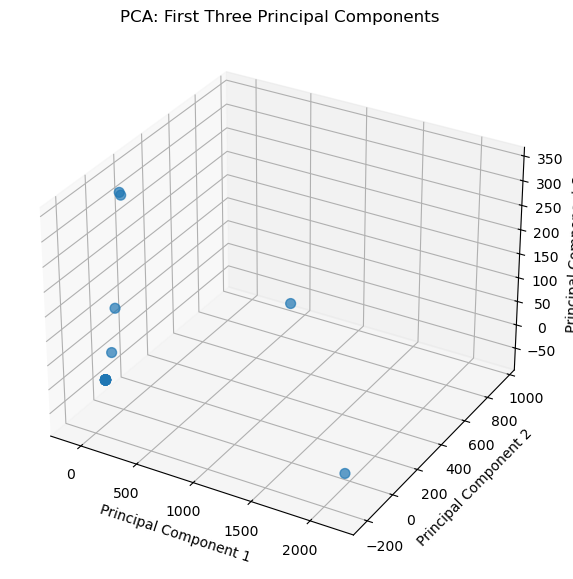

In [11]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pc_df["PC1"], pc_df["PC2"], pc_df["PC3"], alpha=0.7, s=50)

# Labels and title
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("PCA: First Three Principal Components")

# Show plot
plt.show()

# Scree Plot

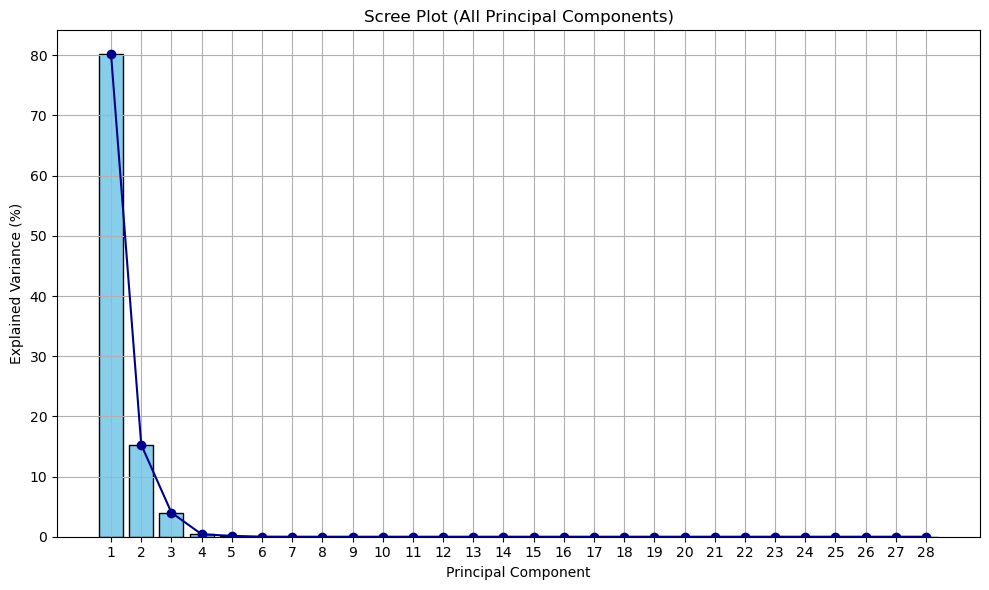

In [12]:

explained_var = pca.explained_variance_ratio_ * 100
num_components = len(explained_var)

plt.figure(figsize=(10, 6))
plt.bar(range(1, num_components + 1), explained_var, color='skyblue', edgecolor='black')
plt.plot(range(1, num_components + 1), explained_var, 'o-', color='darkblue')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot (All Principal Components)")
plt.xticks(range(1, num_components + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# PCA Biplot (PC1 vs PC2)

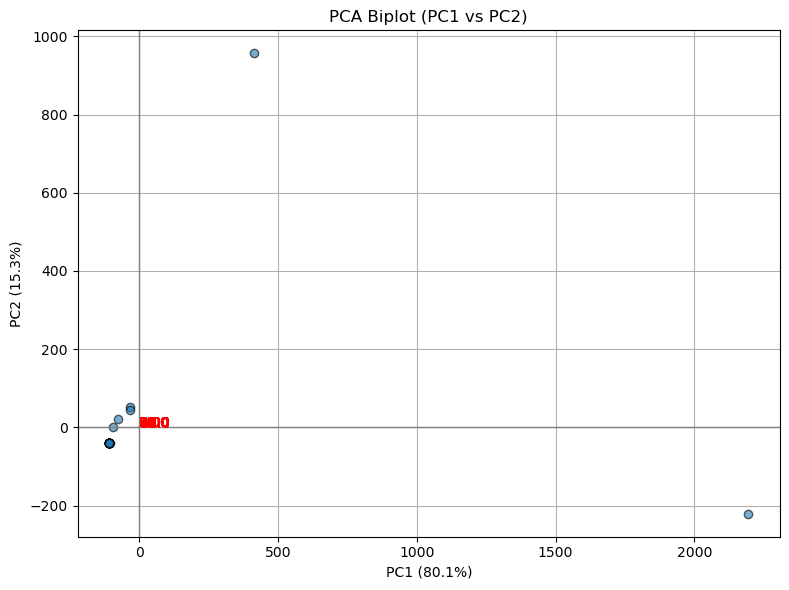

In [13]:

def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    plt.figure(figsize=(8, 6))
    plt.scatter(xs, ys, alpha=0.6, edgecolor='k')

    # Arrows for features
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i, 0]*2, coeff[i, 1]*2, color='r', alpha=0.5, head_width=0.05)
        if labels is not None:
            plt.text(coeff[i, 0]*2.2, coeff[i, 1]*2.2, labels[i], color='r')

    plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    plt.title("PCA Biplot (PC1 vs PC2)")
    plt.grid(True)
    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)
    plt.tight_layout()
    plt.show()

# Call biplot
biplot(principal_components, pca.components_.T, labels=df_transposed.columns)


# Loading plot

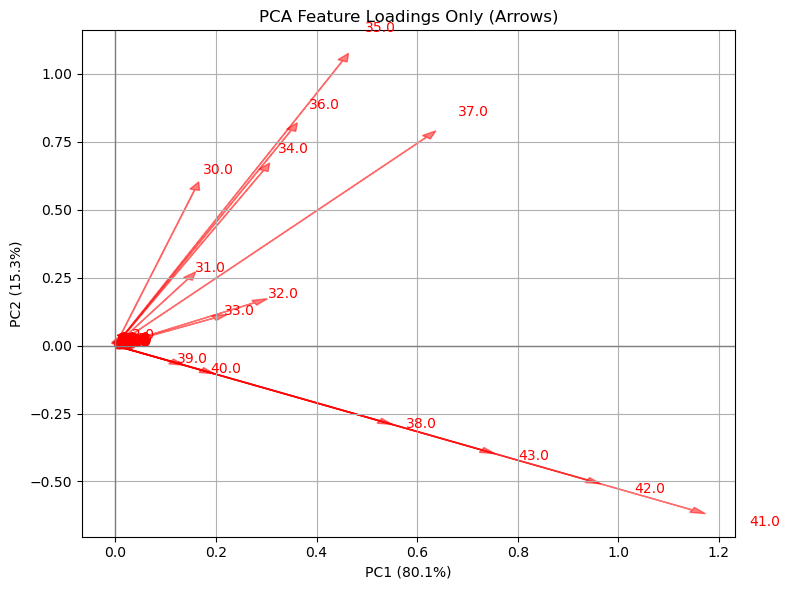

In [14]:


def biplot(score, coeff, labels=None, groups=None):
    plt.figure(figsize=(8, 6))

    # Draw arrows for feature loadings
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i, 0]*2, coeff[i, 1]*2, color='r', alpha=0.5, head_width=0.02)
        if labels is not None:
            plt.text(coeff[i, 0]*2.2, coeff[i, 1]*2.2, labels[i], color='r')

    plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    plt.title("PCA Feature Loadings Only (Arrows)")
    plt.grid(True)
    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)
    plt.tight_layout()
    plt.show()

# Call it
biplot(principal_components, pca.components_.T, labels=df_transposed.columns, groups=None)

# Save a csv file containing the loading values for each feature in loading plot

In [15]:

loading_df = pd.DataFrame(
    pca.components_.T,
    index=df_transposed.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

# Make index a column
loading_df = loading_df.reset_index()

# FORCE rename first column
loading_df.columns = ["Features"] + list(loading_df.columns[1:])

# Export
output_file = f"{base_name}_loading_plot_data.csv"
loading_df.to_csv(output_file, index=False)

print(f"Saved loading data to: {output_file}")

Saved loading data to: LCPC Data for Practicing PCA_loading_plot_data.csv
